In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/processed/BDD_CAPM_nettoyee.xlsx")
df = df.drop(columns=['Symptomatologie '])

def nettoyer_produit(val):
    val = str(val).strip().upper()
    val = re.sub(r'\s+', ' ', val)
    tokens_inconnu = ['INCONNU', 'INCONNUE', 'INCONUE', 'INCONU', 'NP', 'NON PRECISE', 'NON PRÉCISÉ', 'ND']
    return 'INCONNU' if val in tokens_inconnu else val

df['Produit 1'] = df['Produit 1'].apply(nettoyer_produit)

seuil = 50
compte_produits = df['Produit 1'].value_counts()
produits_frequents = compte_produits[compte_produits >= seuil].index.tolist()

df['Produit_Regroupe'] = df['Produit 1'].apply(lambda v: v if v in produits_frequents else 'AUTRE')

print("Dimensions :", df.shape)
print("Catégories Produit_Regroupe :", df['Produit_Regroupe'].nunique())
print("% dans AUTRE :", round(100 * (df['Produit_Regroupe'] == 'AUTRE').sum() / len(df), 1))

Dimensions : (22188, 12)
Catégories Produit_Regroupe : 45
% dans AUTRE : 52.6


In [2]:
from sklearn.model_selection import train_test_split

features = ['Age Année', 'Sexe', 'Milieu', 'Région', 'Circonstance',
            'Sous circonstance', 'type de produit1', ' Voie 1',
            'Tranche_age', 'Produit_Regroupe']

variables_categorielles = ['Sexe', 'Milieu', 'Région', 'Circonstance',
                            'Sous circonstance', 'type de produit1',
                            ' Voie 1', 'Tranche_age', 'Produit_Regroupe']

X = df[features].copy()
y = df['Gradation finale'].copy()

X_encoded = pd.get_dummies(X, columns=variables_categorielles, drop_first=False)
print("Dimensions après encodage :", X_encoded.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Train :", X_train.shape, "  Test :", X_test.shape)

Dimensions après encodage : (22188, 108)
Train : (17750, 108)   Test : (4438, 108)


In [3]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss'))
])

param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [4, 6, 8, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.7, 0.8, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train_encoded)

print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur F1-macro (validation croisée, SMOTE appliqué correctement) :", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'xgb__subsample': 1.0, 'xgb__n_estimators': 200, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0}
Meilleur F1-macro (validation croisée, SMOTE appliqué correctement) : 0.4329665912336827


In [4]:
from sklearn.metrics import classification_report, cohen_kappa_score

best_model = random_search.best_estimator_
y_pred_final_encoded = best_model.predict(X_test)
y_pred_final = le.inverse_transform(y_pred_final_encoded)

print("=== Modèle final combiné (XGBoost + Produit_Regroupe + SMOTE-in-pipeline) ===")
print(classification_report(y_test, y_pred_final, zero_division=0))

y_test_num = y_test.str.extract(r'(\d)').astype(int)[0]
y_pred_num = pd.Series(y_pred_final).str.extract(r'(\d)').astype(int)[0]
qwk_final = cohen_kappa_score(y_test_num, y_pred_num, weights='quadratic')
print("Quadratic Weighted Kappa :", round(qwk_final, 3))

=== Modèle final combiné (XGBoost + Produit_Regroupe + SMOTE-in-pipeline) ===
              precision    recall  f1-score   support

     Grade 0       0.63      0.77      0.69      1586
     Grade 1       0.61      0.36      0.46       713
     Grade 2       0.70      0.71      0.70      1987
     Grade 3       0.33      0.15      0.20       121
     Grade 4       0.50      0.16      0.24        31

    accuracy                           0.65      4438
   macro avg       0.55      0.43      0.46      4438
weighted avg       0.65      0.65      0.64      4438

Quadratic Weighted Kappa : 0.49


In [5]:
probabilites_test = best_model.predict_proba(X_test)
classes_ordre = le.classes_  # ordre des colonnes de probabilites_test
idx_g3 = list(classes_ordre).index(2)  # attention : classes_ordre contient des entiers encodés
idx_g4 = list(classes_ordre).index(3)

# repérer les bons indices selon l'encodage réel
print("Classes encodées et leur ordre :", list(zip(le.classes_, range(len(le.classes_)))))

ValueError: 2 is not in list

In [6]:
probabilites_test = best_model.predict_proba(X_test)

print("Classes et leur position dans le tableau de probabilités :")
print(list(enumerate(le.classes_)))

Classes et leur position dans le tableau de probabilités :
[(0, 'Grade 0'), (1, 'Grade 1'), (2, 'Grade 2'), (3, 'Grade 3'), (4, 'Grade 4')]


In [7]:
idx_g3 = list(le.classes_).index("Grade 3")
idx_g4 = list(le.classes_).index("Grade 4")

proba_severe_test = probabilites_test[:, idx_g3] + probabilites_test[:, idx_g4]
y_test_binaire = y_test.isin(["Grade 3", "Grade 4"]).astype(int)

print("Répartition proba_severe :", pd.Series(proba_severe_test).describe())

Répartition proba_severe : count    4438.000000
mean        0.035943
std         0.088741
min         0.000096
25%         0.004401
50%         0.011538
75%         0.027118
max         0.995291
dtype: float64


In [8]:
seuils_a_tester = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1, 0.08, 0.05]

print(f"{'Seuil':>6} | {'Recall':>8} | {'Precision':>10} | {'Nb alertes':>10}")
print("-" * 45)

for seuil_test in seuils_a_tester:
    y_pred_seuil = (proba_severe_test >= seuil_test).astype(int)
    tp = ((y_pred_seuil == 1) & (y_test_binaire == 1)).sum()
    fp = ((y_pred_seuil == 1) & (y_test_binaire == 0)).sum()
    fn = ((y_pred_seuil == 0) & (y_test_binaire == 1)).sum()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    nb_alertes = y_pred_seuil.sum()
    print(f"{seuil_test:>6.2f} | {rec*100:>7.1f}% | {prec*100:>9.1f}% | {nb_alertes:>10}")

 Seuil |   Recall |  Precision | Nb alertes
---------------------------------------------
  0.50 |    11.2% |      39.5% |         43
  0.40 |    17.1% |      40.6% |         64
  0.30 |    19.1% |      30.9% |         94
  0.25 |    20.4% |      26.7% |        116
  0.20 |    21.7% |      21.9% |        151
  0.15 |    28.9% |      20.2% |        218
  0.10 |    36.8% |      16.3% |        343
  0.08 |    38.2% |      13.9% |        417
  0.05 |    47.4% |      11.2% |        645


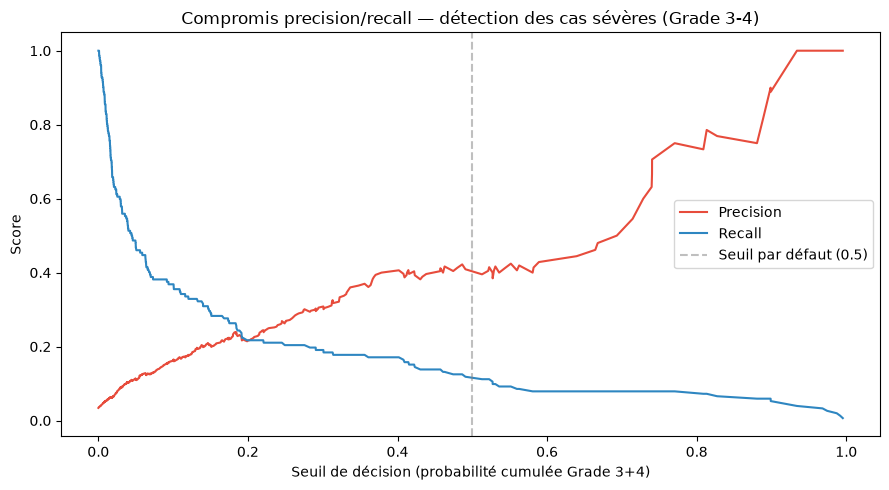

In [9]:
from sklearn.metrics import precision_recall_curve

precision, recall, seuils = precision_recall_curve(y_test_binaire, proba_severe_test)

plt.figure(figsize=(9, 5))
plt.plot(seuils, precision[:-1], label='Precision', color='#e74c3c')
plt.plot(seuils, recall[:-1], label='Recall', color='#2e86c1')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil par défaut (0.5)')
plt.xlabel("Seuil de décision (probabilité cumulée Grade 3+4)")
plt.ylabel("Score")
plt.title("Compromis precision/recall — détection des cas sévères (Grade 3-4)")
plt.legend()
plt.tight_layout()
plt.show()